In [68]:
import matplotlib.pyplot as plt

import pandas as pd

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

from ucimlrepo import fetch_ucirepo

In [69]:
abalone = fetch_ucirepo(id=1) 
x = abalone.data.features 
y = abalone.data.targets 
  
df_real = x.copy()
if y is not None and not y.empty:
    df_real = pd.concat([df_real, y], axis=1)

print(type(df_real))
print(df_real.shape)
df_real.head()

<class 'pandas.DataFrame'>
(4177, 9)


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [70]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df_real)

In [71]:
# Train the synthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df_real)

c:\Users\stasy\Documents\University\Data Engineering\Portfolio\Opdracht 2+3\.venv\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\stasy\Documents\University\Data Engineering\Portfolio\Opdracht 2+3\.venv\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [72]:
# Generate synthetic data
df_synthetic = synthesizer.sample(num_rows=2000)

In [73]:
# Save synthetic data to a CSV file
df_synthetic.to_csv("abalone_synthetic_data.csv", index=False)

In [74]:
df_synthetic.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='str')

In [75]:
numeric_cols = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df_real[numeric_cols].describe()
df_synthetic[numeric_cols].describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.522876,0.406980,0.139402,0.819543,0.355187,0.176925,0.238082,9.951000
std,0.120083,0.099754,0.040543,0.497651,0.224273,0.110832,0.142475,3.283137
min,0.075000,0.055000,0.001000,0.002000,0.001000,0.000500,0.001500,3.000000
25%,0.451000,0.346750,0.111750,0.427950,0.178675,0.087475,0.128250,8.000000
50%,0.537000,0.420000,0.138000,0.754400,0.325100,0.159400,0.217800,9.500000
75%,0.612000,0.479000,0.167000,1.130775,0.492950,0.245300,0.325800,12.000000
max,0.775000,0.622000,0.294000,2.611200,1.201200,0.599400,0.831900,26.000000


Now, let's check the trends of the numerical values, if they are overlapping with the original dataset. It may be smaller in height, due to the amount of data in the synthesized dataset being 2 times smaller.

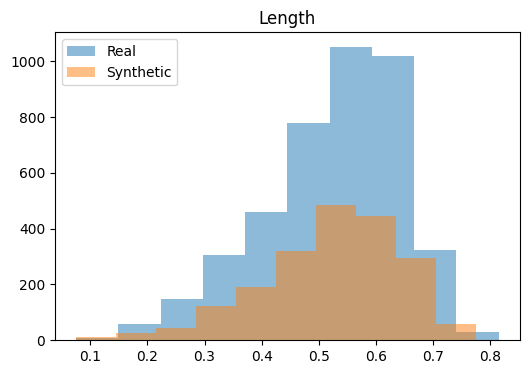

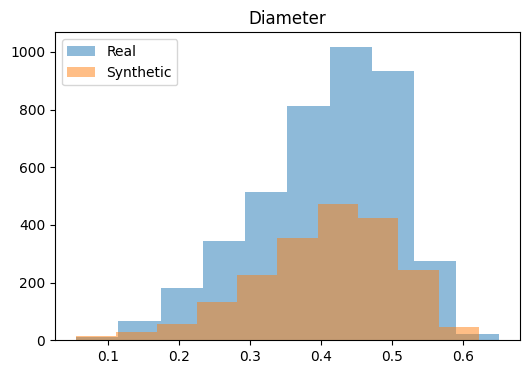

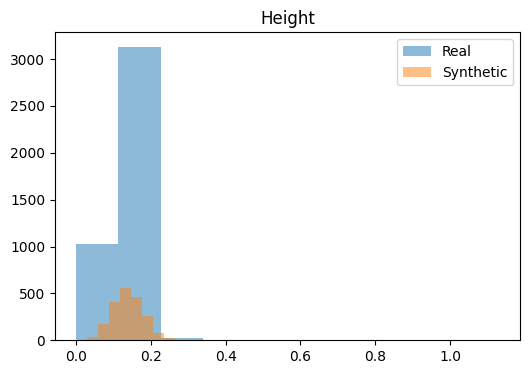

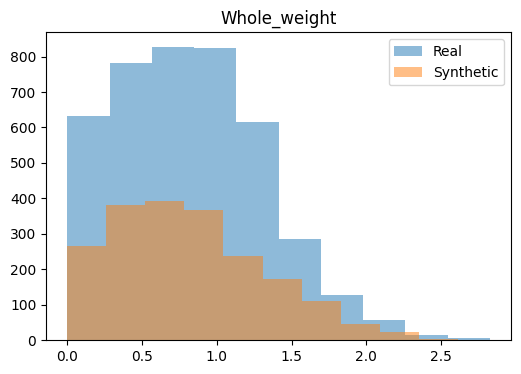

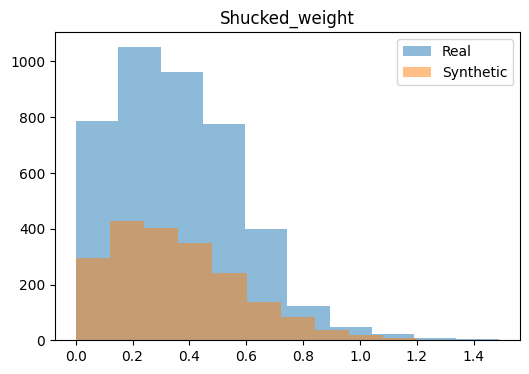

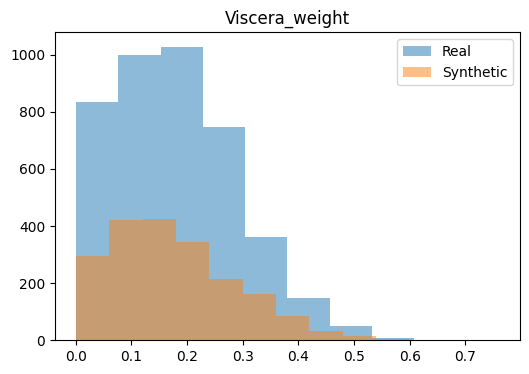

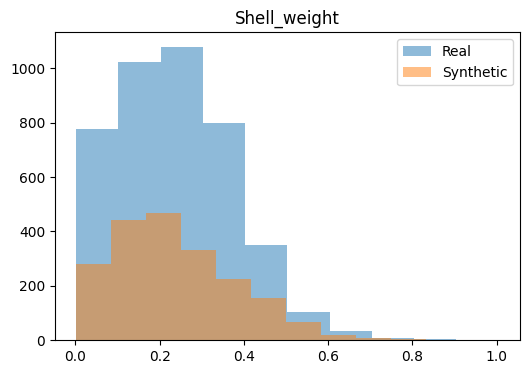

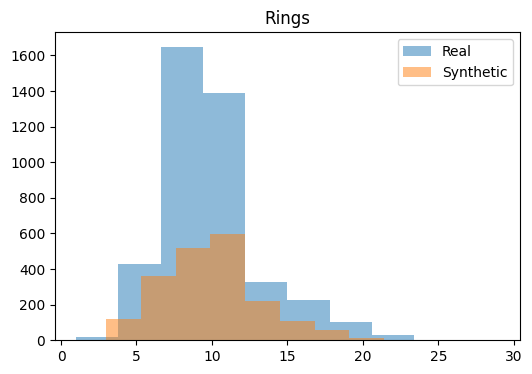

In [76]:
for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(df_real[col], alpha=0.5, label="Real")
    plt.hist(df_synthetic[col], alpha=0.5, label="Synthetic")
    
    plt.title(col)
    plt.legend()
    
    plt.show()

As visible in the graphs above, almost all of them follow their original trends accurate. The only ones, which are not following that accure are the rings and the height. This can be explained, due to the heavy outliers in the height. Now, let's check the categorical values we have.

In [77]:
def compare_categorical(df_real, df_synth, columns):
    
    import matplotlib.pyplot as plt
    
    for col in columns:
        
        real_counts = df_real[col].value_counts(normalize=True)
        synth_counts = df_synth[col].value_counts(normalize=True)

        df_compare = pd.DataFrame({
            "Real": real_counts,
            "Synthetic": synth_counts
        }).fillna(0)

        df_compare.plot(kind="bar")
        
        plt.title(col)
        plt.ylabel("Proportion")
        plt.xticks(rotation=45)
        
        plt.show()

C:\Users\stasy\AppData\Local\Temp\ipykernel_36596\3857145953.py:15: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_compare.plot(kind="bar")


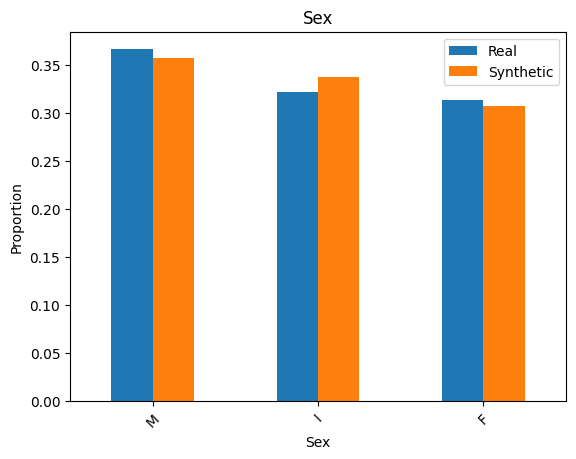

In [78]:
compare_categorical(df_real, df_synthetic, ["Sex"])

As we see here, the values separation is pretty accurate and has only minor differences.